In [2]:
import numpy as np
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import pickle
from utils.data_loader import RainfallDataLoader
rainfall_data_loader = RainfallDataLoader()

### Loading CHIRPS data

In [3]:
chirps_data_dict = rainfall_data_loader.get_chirps_data(reproject_to_era5=False)
chirps_dates = list(chirps_data_dict.keys())
chirps_dataset = list(chirps_data_dict.values())
chirps_dates = np.array(chirps_dates)
chirps_dataset = np.array(chirps_dataset)

Loading CHIRPS Data: 100%|██████████| 16314/16314 [00:03<00:00, 4474.33it/s]


In [4]:
chirps_data_dict = rainfall_data_loader.get_chirps_data(reproject_to_era5=True)
chirps_dates = list(chirps_data_dict.keys())
chirps_reprojectd_dataset = list(chirps_data_dict.values())
chirps_dates = np.array(chirps_dates)
chirps_reprojectd_dataset = np.array(chirps_reprojectd_dataset)

Reprojecting and Loading CHIRPS Data: 16314it [00:00, 12780327.88it/s]         ?, ?it/s]


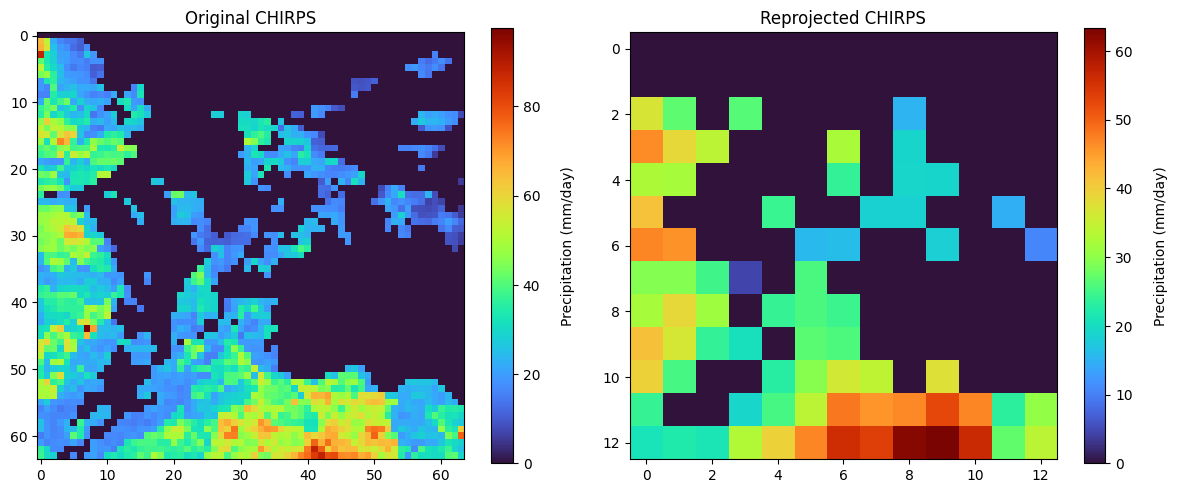

In [5]:
i = -1
plt.figure(figsize=(12, 7))

plt.subplot(121)
img = plt.imshow(chirps_dataset[i], cmap="turbo")
cbar = plt.colorbar(img, shrink=0.65)
cbar.set_label("Precipitation (mm/day)", rotation=90, labelpad=15)
plt.title("Original CHIRPS")

plt.subplot(122)
img = plt.imshow(chirps_reprojectd_dataset[i], cmap="turbo")
cbar = plt.colorbar(img, shrink=0.65)
cbar.set_label("Precipitation (mm/day)", rotation=90, labelpad=15)
plt.title("Reprojected CHIRPS")

plt.tight_layout()

### Filtering dataset

In [6]:
def detect_clusters_and_filter(image, percent_area_threshold=0.01, density_threshold=0.05):
    """
    Detects connected clusters in a binary image and filters based on
    relative area (percentage of total image) and density threshold.

    Parameters:
        image (ndarray): Input grayscale or binary image
        percent_area_threshold (float): Minimum area fraction of total image (e.g. 0.01 = 1%)
        density_threshold (float): Minimum total cluster density threshold (0–1)

    Returns:
        has_sufficient_density (bool): True if total large-cluster density ≥ threshold
        large_clusters (list): List of dicts with area, bbox, centroid
        image (ndarray): Original image (unchanged)
    """
    if image is None:
        return False, [], None

    # Convert to binary
    _, binary = cv2.threshold(image, 16, 255, cv2.THRESH_BINARY)

    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # Compute total image area
    image_area = image.shape[0] * image.shape[1]

    # Convert percent threshold to absolute pixel area
    area_threshold = percent_area_threshold * image_area

    large_clusters = []
    total_large_cluster_area = 0

    for i in range(1, num_labels):  # Skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area > area_threshold:
            large_clusters.append({
                'area': area,
                'bbox': stats[i, :4],
                'centroid': centroids[i]
            })
            total_large_cluster_area += area

    # Calculate overall cluster density
    density = total_large_cluster_area / image_area
    has_sufficient_density = density >= density_threshold

    return has_sufficient_density, large_clusters, image

def interplolate_image(img, size=(64, 64)):
    resized_img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return resized_img

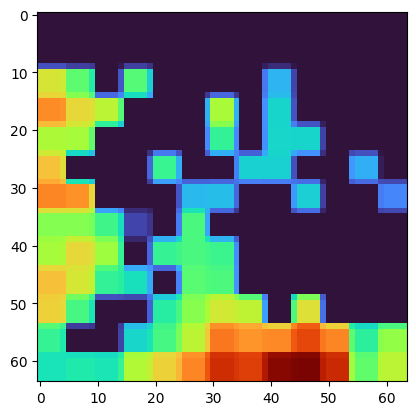

In [7]:
plt.imshow(interplolate_image(chirps_reprojectd_dataset[-1]), cmap="turbo")

100%|██████████| 16314/16314 [00:00<00:00, 27916.85it/s]

Final length of data =  682


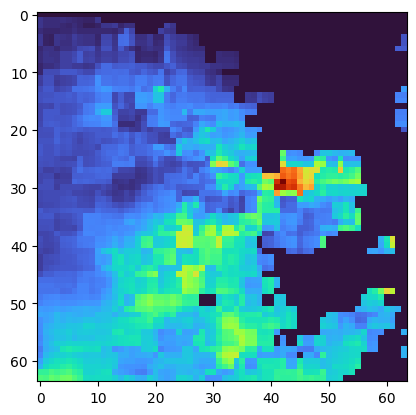

In [28]:
filtered_chirps = []
filtered_chirps_reprojected = []
filtered_dates = []
YEAR_THRESHOLD = 1999
PERCENT_AREA_THRESHOLD = 0.2
for date, chirps, chirps_reprojectd in tqdm(list(zip(chirps_dates, chirps_dataset, chirps_reprojectd_dataset))):
    has_sufficient_density, _, _ = detect_clusters_and_filter(chirps.astype(np.uint8), percent_area_threshold=PERCENT_AREA_THRESHOLD)
    if has_sufficient_density:
        if date.year < YEAR_THRESHOLD: # Removing data before 1999 | Because they are all blocky and does not match pattern of data after 1999
            continue
        filtered_chirps.append(chirps)
        resized_chirps_reprojected = interplolate_image(chirps_reprojectd)
        filtered_chirps_reprojected.append(resized_chirps_reprojected)
        filtered_dates.append(date)

filtered_chirps = np.array(filtered_chirps)
filtered_chirps_reprojected = np.array(filtered_chirps_reprojected)
print("Final length of data = ", len(filtered_chirps))
plt.imshow(filtered_chirps[0], cmap="turbo")

In [29]:
chirps_dict = {}
chirps_reprojected_dict = {}
for date, chirps in zip(filtered_dates, filtered_chirps):
    chirps_dict[date] = chirps
for date, chirps in zip(filtered_dates, filtered_chirps_reprojected):
    chirps_reprojected_dict[date] = chirps

Text(0.5, 0, 'Precipitation (mm/d)')

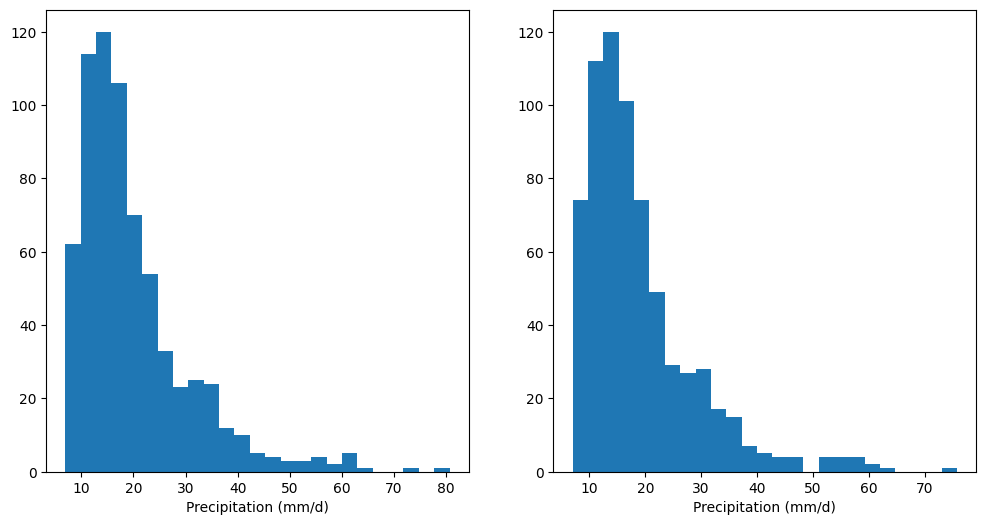

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(filtered_chirps.mean(axis=(1,2)), bins=25)
axs[0].set_xlabel("Precipitation (mm/d)")

axs[1].hist(filtered_chirps_reprojected.mean(axis=(1,2)), bins=25)
axs[1].set_xlabel("Precipitation (mm/d)")

## Save data

In [31]:
import os
try:
    os.mkdir("./data")
except FileExistsError:
    print("'data' directory already exists.")

print("Saving Datasets")
with open('./data/filtered_chirps.pkl', 'wb') as file:
    pickle.dump(chirps_dict, file)

with open('./data/filterd_chirps_reprojected.pkl', 'wb') as file:
    pickle.dump(chirps_reprojected_dict, file)

'data' directory already exists.
Saving Datasets


In [ ]:
# for date, img in zip(filtered_dates, filtered_chirps):
#     plt.imshow(img, cmap="turbo")
#     plt.title(f"{date}")

ValueError: Invalid affine transformation matrix

<Figure size 640x480 with 1 Axes>